# TCA Demo Data: 3 Symbols × 3 Days (via di.simcalendar)

Generates a demo-sized TCA dataset using **real trading-day continuity**: each symbol is simulated across 3 consecutive days via `di.simcalendar`, with each day's closing price carried forward as the next day's opening price - not 3 independent single-day runs.

| Symbol | Regime | Liquidity tier |
|---|---|---|
| NVDA | volatile | ~500K trades/day |
| XOM | jumpy | ~82K trades/day |
| PG | default | ~52K trades/day |

Each symbol/day gets a `good` and `bad` execution order - 9 symbol-days × 2 orders = **18 orders total**.

This stays fast enough for a live demo (verified: ~9s for 3 days of NVDA at full trade-count calibration). Large-scale performance testing is a separate, offline exercise.

## Setup

In [1]:
import os
import pykx as kx
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

module_path = os.path.expanduser('~/kdbx-modules')
tick_presets_path = f"{module_path}/di/simtick/presets.csv"
order_presets_path = f"{module_path}/di/simorder/presets.csv"
calendar_path = f"{module_path}/di/simcalendar/calendar.csv"

kx.q(f'setenv[`QPATH;"{module_path}"]')
kx.q('simtick:use`di.simtick')
kx.q('simcalendar:use`di.simcalendar')
kx.q('simorder:use`di.simorder')
kx.q(f'tickcfgs:simtick.loadconfig`$":{tick_presets_path}"')
kx.q(f'ordcfgs:simorder.loadconfig`$":{order_presets_path}"')
kx.q(f'cal:simcalendar.loadcalendar`$":{calendar_path}"')

print("Modules loaded successfully!")
print("Calendar:", kx.q('cal').pd().tolist())


Welcome to KDB-X Community Edition!
For Community support, please visit https://kx.com/slack
Tutorials can be found at https://github.com/KxSystems/tutorials
Ready to go beyond the Community Edition? Email preview@kx.com

Modules loaded successfully!
Calendar: [Timestamp('2026-08-18 00:00:00'), Timestamp('2026-08-19 00:00:00'), Timestamp('2026-08-20 00:00:00')]


## Define the demo dataset

In [2]:
# (ticker, tick preset name)
SYMBOLS = [
    ('NVDA', 'nvda_volatile'),
    ('XOM',  'xom_jumpy'),
    ('PG',   'pg_default'),
]

# must match calendar.csv exactly
DAYS = ['2026.08.18', '2026.08.19', '2026.08.20']

print(f"{len(SYMBOLS)} symbols x {len(DAYS)} days = {len(SYMBOLS) * len(DAYS)} symbol-days")
print(f"x 2 orders (good/bad) = {len(SYMBOLS) * len(DAYS) * 2} orders total")

3 symbols x 3 days = 9 symbol-days
x 2 orders (good/bad) = 18 orders total


## Generate market data (per symbol, via di.simcalendar)

One `simcalendar.run` call per symbol - each produces a continuous 3-day price path for that symbol.

In [3]:
all_trades, all_quotes = [], []

for sym, preset in SYMBOLS:
    kx.q(f'result:simcalendar.run[tickcfgs`{preset};cal;(::)]')
    trades_sym = kx.q('result`trade').pd()
    quotes_sym = kx.q('result`quote').pd()
    all_trades.append(trades_sym)
    all_quotes.append(quotes_sym)
    print(f"{sym} ({preset}): {len(trades_sym):,} trades, {len(quotes_sym):,} quotes across 3 days")

print()
print("Price continuity check (day close -> next day open should match closely):")
for i, (sym, preset) in enumerate(SYMBOLS):
    t = all_trades[i].copy()
    t['date'] = t['time'].dt.date
    display(t.groupby('date')['price'].agg(first_trade='first', last_trade='last'))

NVDA (nvda_volatile): 1,743,930 trades, 1,745,660 quotes across 3 days
XOM (xom_jumpy): 245,189 trades, 304,071 quotes across 3 days
PG (pg_default): 154,351 trades, 234,803 quotes across 3 days

Price continuity check (day close -> next day open should match closely):


,first_trade,last_trade
date,,
2026-08-18,215.01,212.16
2026-08-19,212.16,213.48
2026-08-20,213.46,218.88


,first_trade,last_trade
date,,
2026-08-18,166.01,165.14
2026-08-19,165.15,170.98
2026-08-20,170.99,172.05


,first_trade,last_trade
date,,
2026-08-18,140.97,144.92
2026-08-19,144.89,146.95
2026-08-20,146.95,141.59


## Visualize: 3-day price path per symbol

One panel per symbol, showing its continuous price path across all 3 days (dashed lines mark day boundaries - the price should not jump at these lines, confirming continuity). Each symbol uses a different market regime, so the panels also show that character directly: NVDA (volatile) choppier, XOM (jumpy) with visible discontinuities, PG (default) calmer.

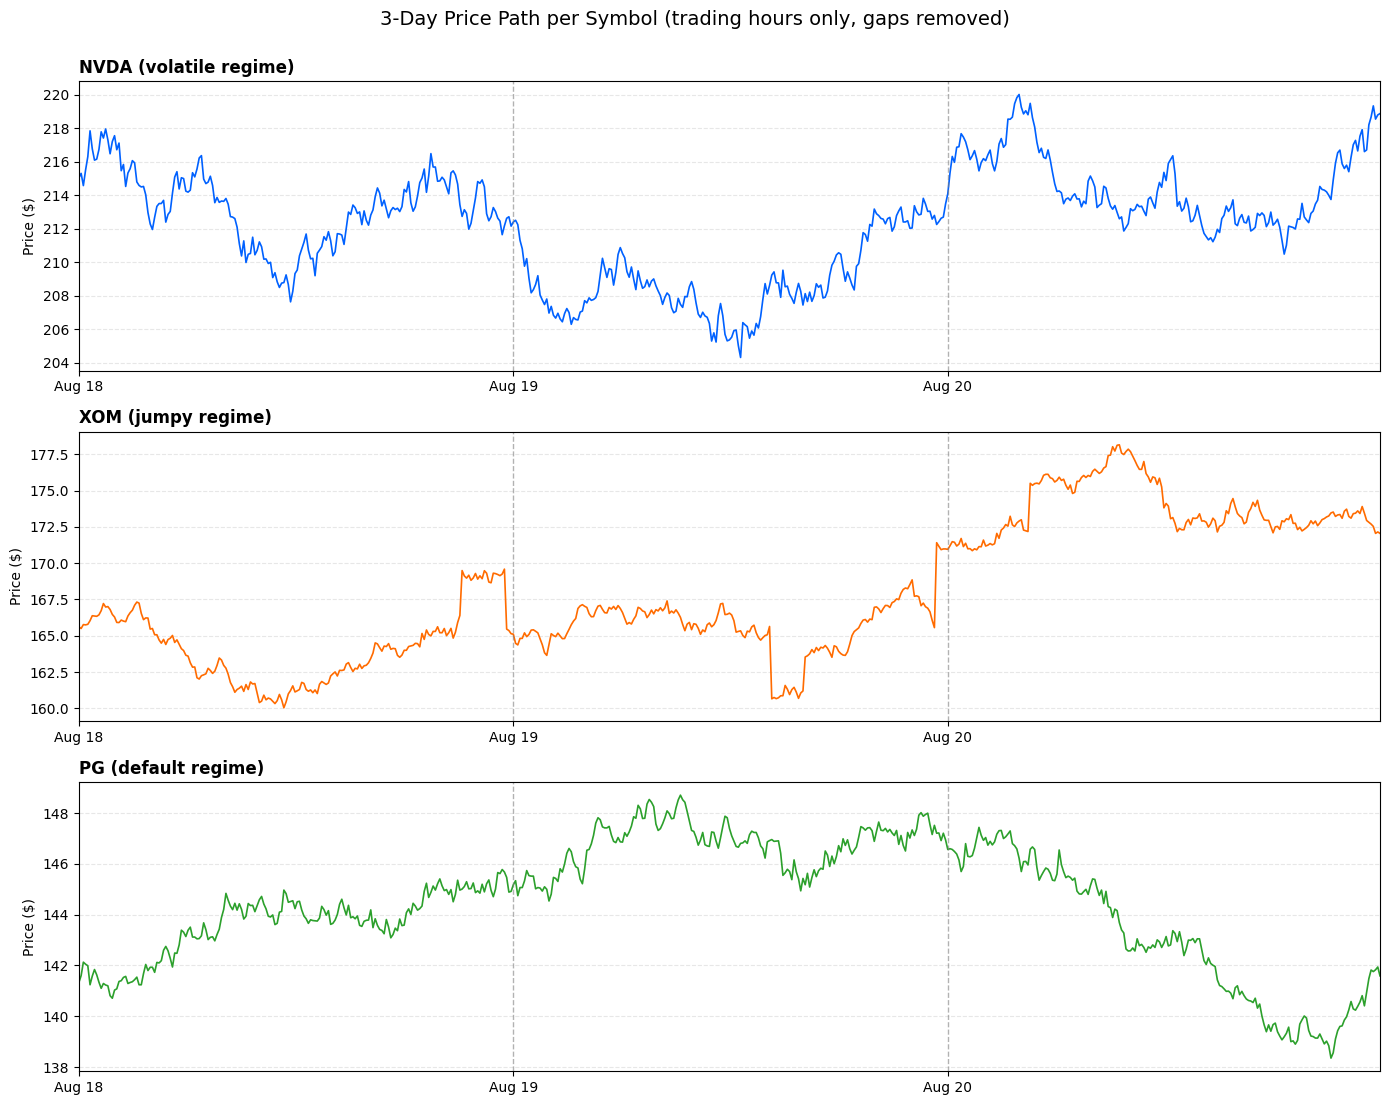

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))
colors = ['#0061FF', '#FF6B00', '#2ca02c']

for ax, (sym, preset), color, trades_sym in zip(axes, SYMBOLS, colors, all_trades):
    # resample within trading hours only, then drop non-trading (overnight) bins
    t = trades_sym.set_index('time')['price'].resample('2min').last().dropna()

    # positional x-axis: consecutive bins are evenly spaced regardless of the
    # real elapsed time between them, so overnight gaps take up zero width
    x_pos = range(len(t))
    ax.plot(x_pos, t.values, color=color, linewidth=1.2)

    # day boundaries: find where the calendar date changes, mark + label them
    dates = t.index.date
    day_start_positions = [0] + [i for i in range(1, len(dates)) if dates[i] != dates[i - 1]]
    day_labels = [pd.Timestamp(dates[i]).strftime('%b %d') for i in day_start_positions]

    for pos in day_start_positions[1:]:
        ax.axvline(pos, color='grey', linestyle='--', linewidth=1, alpha=0.6)

    ax.set_xticks(day_start_positions)
    ax.set_xticklabels(day_labels)
    ax.set_xlim(0, len(t) - 1)
    ax.set_title(f'{sym} ({preset.split("_")[1]} regime)', fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel('Price ($)')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

fig.suptitle('3-Day Price Path per Symbol (trading hours only, gaps removed)', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

## Generate orders + executions

For each symbol/day, run `di.simorder` twice (good/bad presets) against that symbol's own 3-day trades/quotes, with a unique order ID per symbol-day-style.

In [5]:
all_orders, all_executions = [], []

for sym, preset in SYMBOLS:
    kx.q(f'result:simcalendar.run[tickcfgs`{preset};cal;(::)]')

    for date in DAYS:
        starttime = f"{date}D09:35:00.000000000"
        endtime = f"{date}D09:45:00.000000000"
        good_id = f"ORD_{sym}_{date.replace('.', '')}_GOOD"
        bad_id = f"ORD_{sym}_{date.replace('.', '')}_BAD"

        kx.q(f'''
        goodcfg:ordcfgs`good;
        goodcfg[`orderid]:`{good_id};
        goodcfg[`sym]:`{sym};
        goodcfg[`starttime]:{starttime};
        goodcfg[`endtime]:{endtime};
        goodresult:simorder.run[goodcfg;result`trade;result`quote];

        badcfg:ordcfgs`bad;
        badcfg[`orderid]:`{bad_id};
        badcfg[`sym]:`{sym};
        badcfg[`starttime]:{starttime};
        badcfg[`endtime]:{endtime};
        badresult:simorder.run[badcfg;result`trade;result`quote];

        orders_i:goodresult[`order],badresult[`order];
        executions_i:goodresult[`executions],badresult[`executions];
        ''')
        orders_i = kx.q('orders_i').pd()
        executions_i = kx.q('executions_i').pd()

        all_orders.append(orders_i)
        all_executions.append(executions_i)

        print(f"{sym} {date}: 2 orders generated ({good_id}, {bad_id})")

orders = pd.concat(all_orders, ignore_index=True)
executions = pd.concat(all_executions, ignore_index=True)
trades = pd.concat(all_trades, ignore_index=True)
quotes = pd.concat(all_quotes, ignore_index=True)

print()
print(f"Total: {len(trades):,} trades, {len(quotes):,} quotes, {len(orders)} orders, {len(executions)} executions")

NVDA 2026.08.18: 2 orders generated (ORD_NVDA_20260818_GOOD, ORD_NVDA_20260818_BAD)
NVDA 2026.08.19: 2 orders generated (ORD_NVDA_20260819_GOOD, ORD_NVDA_20260819_BAD)
NVDA 2026.08.20: 2 orders generated (ORD_NVDA_20260820_GOOD, ORD_NVDA_20260820_BAD)
XOM 2026.08.18: 2 orders generated (ORD_XOM_20260818_GOOD, ORD_XOM_20260818_BAD)
XOM 2026.08.19: 2 orders generated (ORD_XOM_20260819_GOOD, ORD_XOM_20260819_BAD)
XOM 2026.08.20: 2 orders generated (ORD_XOM_20260820_GOOD, ORD_XOM_20260820_BAD)
PG 2026.08.18: 2 orders generated (ORD_PG_20260818_GOOD, ORD_PG_20260818_BAD)
PG 2026.08.19: 2 orders generated (ORD_PG_20260819_GOOD, ORD_PG_20260819_BAD)
PG 2026.08.20: 2 orders generated (ORD_PG_20260820_GOOD, ORD_PG_20260820_BAD)

Total: 2,143,470 trades, 2,284,534 quotes, 18 orders, 360 executions


## Sanity check: quantity conservation across all 18 orders

In [6]:
qty_check = executions.groupby('orderid')['qty'].sum().reset_index().merge(
    orders[['orderid', 'orderqty']], on='orderid'
)
if (qty_check['qty'] == qty_check['orderqty']).all():
    print(f'✓  All {len(qty_check)} orders: execution quantities sum exactly to orderqty')
else:
    print('⚠  Quantity mismatch detected:')
    display(qty_check[qty_check['qty'] != qty_check['orderqty']])

✓  All 18 orders: execution quantities sum exactly to orderqty


## Visualize: good vs. bad execution cost, all 18 orders

Implementation shortfall (bps vs. arrival price) for every order, grouped by symbol/day. Green = good execution, red = bad. Positive = cost, negative = savings.

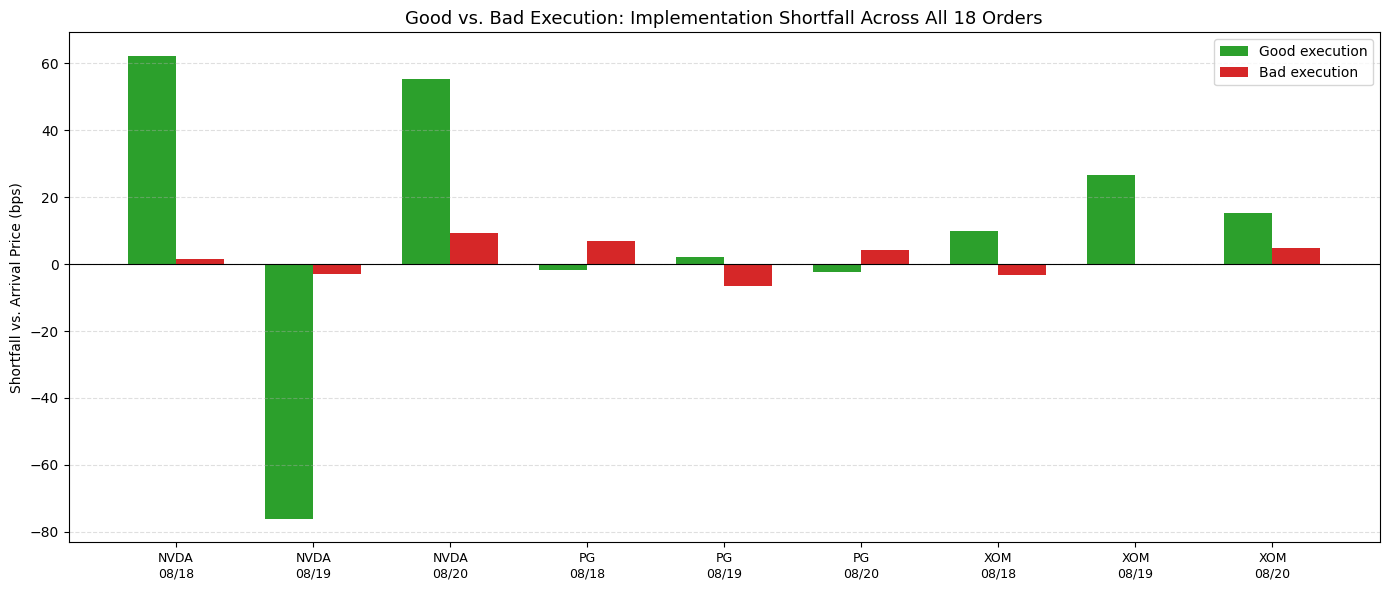

In [7]:
summary = (
    executions.groupby('orderid')
    .apply(lambda g: (g['price'] * g['qty']).sum() / g['qty'].sum(), include_groups=False)
    .rename('execution_vwap')
    .reset_index()
    .merge(orders[['orderid', 'sym', 'side', 'starttime', 'arrivalprice']], on='orderid')
)
summary['shortfall_bps'] = 10000 * (summary['execution_vwap'] - summary['arrivalprice']) / summary['arrivalprice']
summary['style'] = summary['orderid'].str.contains('GOOD').map({True: 'Good', False: 'Bad'})
summary['label'] = summary['sym'] + '\n' + pd.to_datetime(summary['starttime']).dt.strftime('%m/%d')
summary = summary.sort_values(['sym', 'starttime'])

labels = summary['label'].unique()
x = range(len(labels))
good_vals = [summary[(summary['label'] == l) & (summary['style'] == 'Good')]['shortfall_bps'].values[0] for l in labels]
bad_vals = [summary[(summary['label'] == l) & (summary['style'] == 'Bad')]['shortfall_bps'].values[0] for l in labels]

fig, ax = plt.subplots(figsize=(14, 6))
width = 0.35
ax.bar([i - width/2 for i in x], good_vals, width, label='Good execution', color='#2ca02c')
ax.bar([i + width/2 for i in x], bad_vals, width, label='Bad execution', color='#d62728')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Shortfall vs. Arrival Price (bps)')
ax.set_title('Good vs. Bad Execution: Implementation Shortfall Across All 18 Orders', fontsize=13)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Export all four tables to Parquet

In [8]:
output_dir = Path(module_path) / 'data'
output_dir.mkdir(exist_ok=True)

tables = {
    'trades': trades,
    'quotes': quotes,
    'orders': orders,
    'executions': executions,
}

for name, df in tables.items():
    path = output_dir / f'{name}.parquet'
    pq.write_table(pa.Table.from_pandas(df, preserve_index=False), path)
    size_kb = path.stat().st_size / 1024
    print(f'{name}.parquet written ({size_kb:.1f} KB, {len(df):,} rows)')

trades.parquet written (20224.1 KB, 2,143,470 rows)
quotes.parquet written (26869.2 KB, 2,284,534 rows)
orders.parquet written (5.2 KB, 18 rows)
executions.parquet written (8.7 KB, 360 rows)


## Verify

In [9]:
for name in tables:
    path = output_dir / f'{name}.parquet'
    t = pq.read_table(path)
    print(f'--- {name} ---')
    print(f'rows: {t.num_rows}, columns: {t.column_names}')
    display(t.to_pandas().head(3))
    print()

--- trades ---
rows: 2143470, columns: ['sym', 'time', 'price', 'qty']


,sym,time,price,qty
0,NVDA,2026-08-18 09:30:00.116580954,215.01,322
1,NVDA,2026-08-18 09:30:00.240416685,215.05,316
2,NVDA,2026-08-18 09:30:00.279988142,215.05,51



--- quotes ---
rows: 2284534, columns: ['sym', 'time', 'bid', 'ask', 'bidsize', 'asksize']


,sym,time,bid,ask,bidsize,asksize
0,NVDA,2026-08-18 09:30:00.028580954,215.00,215.03,500,500
1,NVDA,2026-08-18 09:30:00.058580954,215.00,215.03,574,527
2,NVDA,2026-08-18 09:30:00.162416685,215.04,215.07,471,342



--- orders ---
rows: 18, columns: ['orderid', 'sym', 'side', 'orderqty', 'starttime', 'endtime', 'arrivalprice']


,orderid,sym,side,orderqty,starttime,endtime,arrivalprice
0,ORD_NVDA_20260818_GOOD,NVDA,BUY,10000,2026-08-18 09:35:00,2026-08-18 09:45:00,214.845
1,ORD_NVDA_20260818_BAD,NVDA,BUY,10000,2026-08-18 09:35:00,2026-08-18 09:45:00,214.845
2,ORD_NVDA_20260819_GOOD,NVDA,BUY,10000,2026-08-19 09:35:00,2026-08-19 09:45:00,212.595



--- executions ---
rows: 360, columns: ['orderid', 'execid', 'sym', 'side', 'time', 'price', 'qty']


,orderid,execid,sym,side,time,price,qty
0,ORD_NVDA_20260818_GOOD,1,NVDA,BUY,2026-08-18 09:35:28.571428571,214.43,471
1,ORD_NVDA_20260818_GOOD,2,NVDA,BUY,2026-08-18 09:35:57.142857143,214.49,530
2,ORD_NVDA_20260818_GOOD,3,NVDA,BUY,2026-08-18 09:36:25.714285714,214.97,489
